In [81]:
import os
import cv2
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from detectron2.engine import DefaultPredictor
from detectron2.config import get_cfg
from detectron2 import model_zoo
from detectron2.utils.visualizer import Visualizer
from detectron2.data import MetadataCatalog
import os
import cv2
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from ultralytics import YOLO
import pandas as pd


In [18]:
# define dataset parent directory
data_dir = os.path.abspath("../data/all_cropped")

Processing Chaos_Co.tif...


/Users/jjwill18/miniforge3/envs/chaos_ml_env/lib/python3.11/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /Users/runner/miniforge3/conda-bld/libtorch_1786372171945/work/aten/src/ATen/native/TensorShape.cpp:4217.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
[W1009 12:27:57.484145000 MPSFallback.mm:34] Warning: The operator 'torchvision::nms' is not currently supported on the MPS backend and will fall back to run on the CPU. This may have performance implications. (function operator())
W1009 12:27:57.361000 71318 site-packages/torch/fx/_symbolic_trace.py:56] is_fx_tracing will return true for both fx.symbolic_trace and torch.export. Please use is_fx_tracing_symbolic_tracing() for specifically fx.symbolic_trace or torch.compiler.is_compiling() for specifically torch.export/compile.


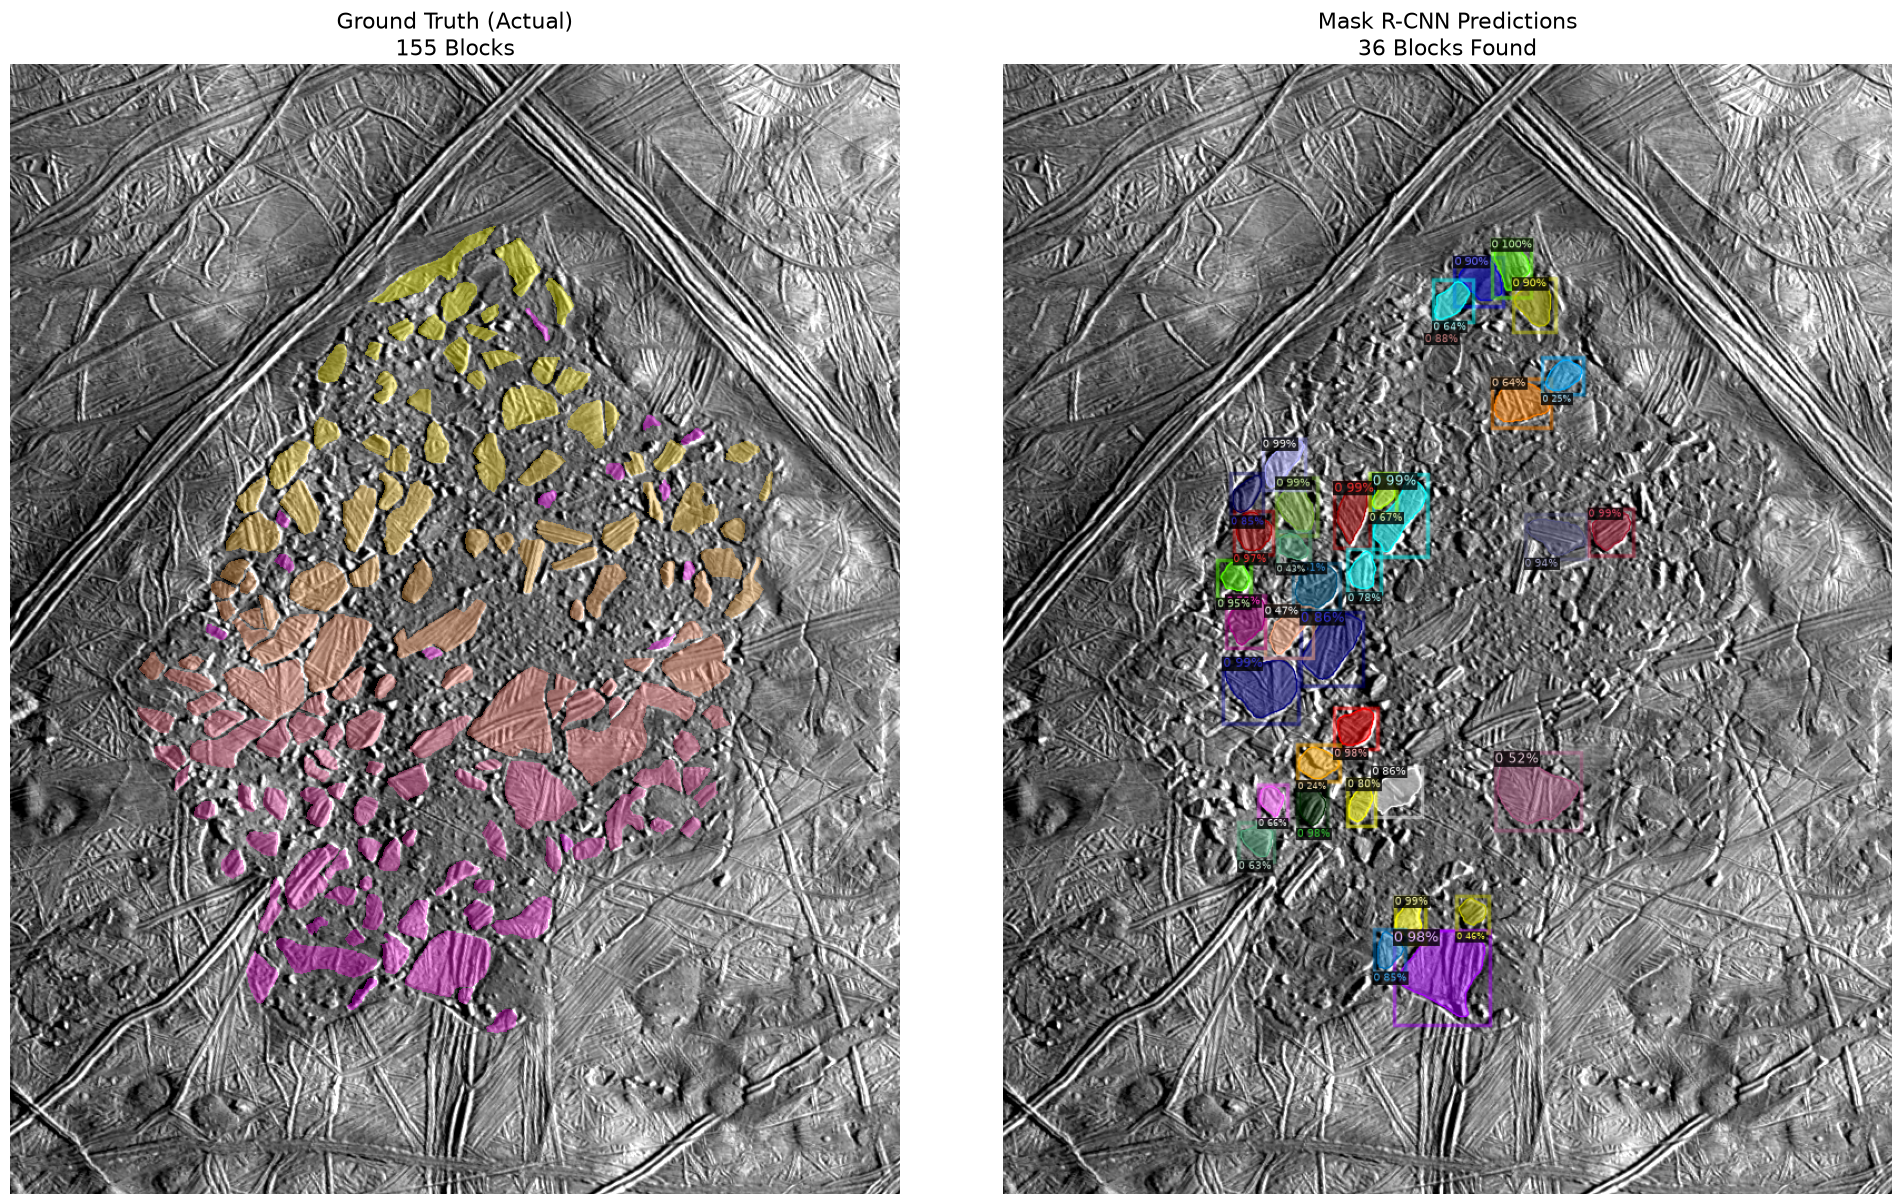

In [9]:
# define the model run to visualize
model_run = "run_10_maskrcnn"

# define directories to ground truth image/mask and model weights
img_path = os.path.join(data_dir, 'stitched/images/Chaos_Co.tif')
mask_path = os.path.join(data_dir, 'stitched/masks/Chaos_Co.tif')
weights_path = f"../results/runs/{model_run}/model_final.pth"

# configure Detectron2
cfg = get_cfg()
cfg.merge_from_file(model_zoo.get_config_file("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml"))
cfg.MODEL.ROI_HEADS.NUM_CLASSES = 1
cfg.MODEL.DEVICE = "mps"
cfg.MODEL.WEIGHTS = weights_path
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.20 # confidence level for showing blocks

predictor = DefaultPredictor(cfg)
chaos_metadata = MetadataCatalog.get("chaos_train") 

# read in and normalise the tiff image
print(f"Processing {os.path.basename(img_path)}...")
with rasterio.open(img_path) as src:
    img_data = src.read(1)
    
    # global normalization
    valid_pixels = img_data[~np.isnan(img_data)]
    vmin, vmax = np.percentile(valid_pixels, [2, 98])
    
    # clean and scale to 8-bit
    img_data = np.nan_to_num(img_data, nan=vmin)
    img_data = np.clip((img_data - vmin) / (vmax - vmin), 0, 1)
    img_8bit = (img_data * 255).astype(np.uint8)
    
    # convert to RGB for visualization, and BGR for Detectron2 inference
    img_rgb = cv2.cvtColor(img_8bit, cv2.COLOR_GRAY2RGB)
    img_bgr = img_rgb[:, :, ::-1]

# read the ground truth
with rasterio.open(mask_path) as src:
    true_mask = src.read(1)

# run model prediction
outputs = predictor(img_bgr)

# use Detectron2's built-in visualizer to draw predicted masks
v = Visualizer(img_rgb, metadata=chaos_metadata, scale=1.0)
v = v.draw_instance_predictions(outputs["instances"].to("cpu"))
predicted_img = v.get_image()

# plot both side by side
fig, axes = plt.subplots(1, 2, figsize=(20, 12))

# ground truth
axes[0].imshow(img_rgb)
transparent_true_mask = np.ma.masked_where(true_mask == 0, true_mask)
axes[0].imshow(transparent_true_mask, cmap='spring', alpha=0.4, interpolation='nearest')
axes[0].set_title(f"Ground Truth (Actual)\n{len(np.unique(true_mask))-1} Blocks", fontsize=16)
axes[0].axis('off')

# model predictions
num_predictions = len(outputs["instances"])
axes[1].imshow(predicted_img)
axes[1].set_title(f"Mask R-CNN Predictions\n{num_predictions} Blocks Found", fontsize=16)
axes[1].axis('off')

plt.tight_layout()
plt.show()

Processing Chaos_Co.tif...

WARNING ⚠️ imgsz=[1016, 800] must be multiple of max stride 32, updating to [1024, 800]
0: 1024x800 157 chaos_blocks, 16.9ms
Speed: 1.3ms preprocess, 16.9ms inference, 85.7ms postprocess per image at shape (1, 3, 1024, 800)


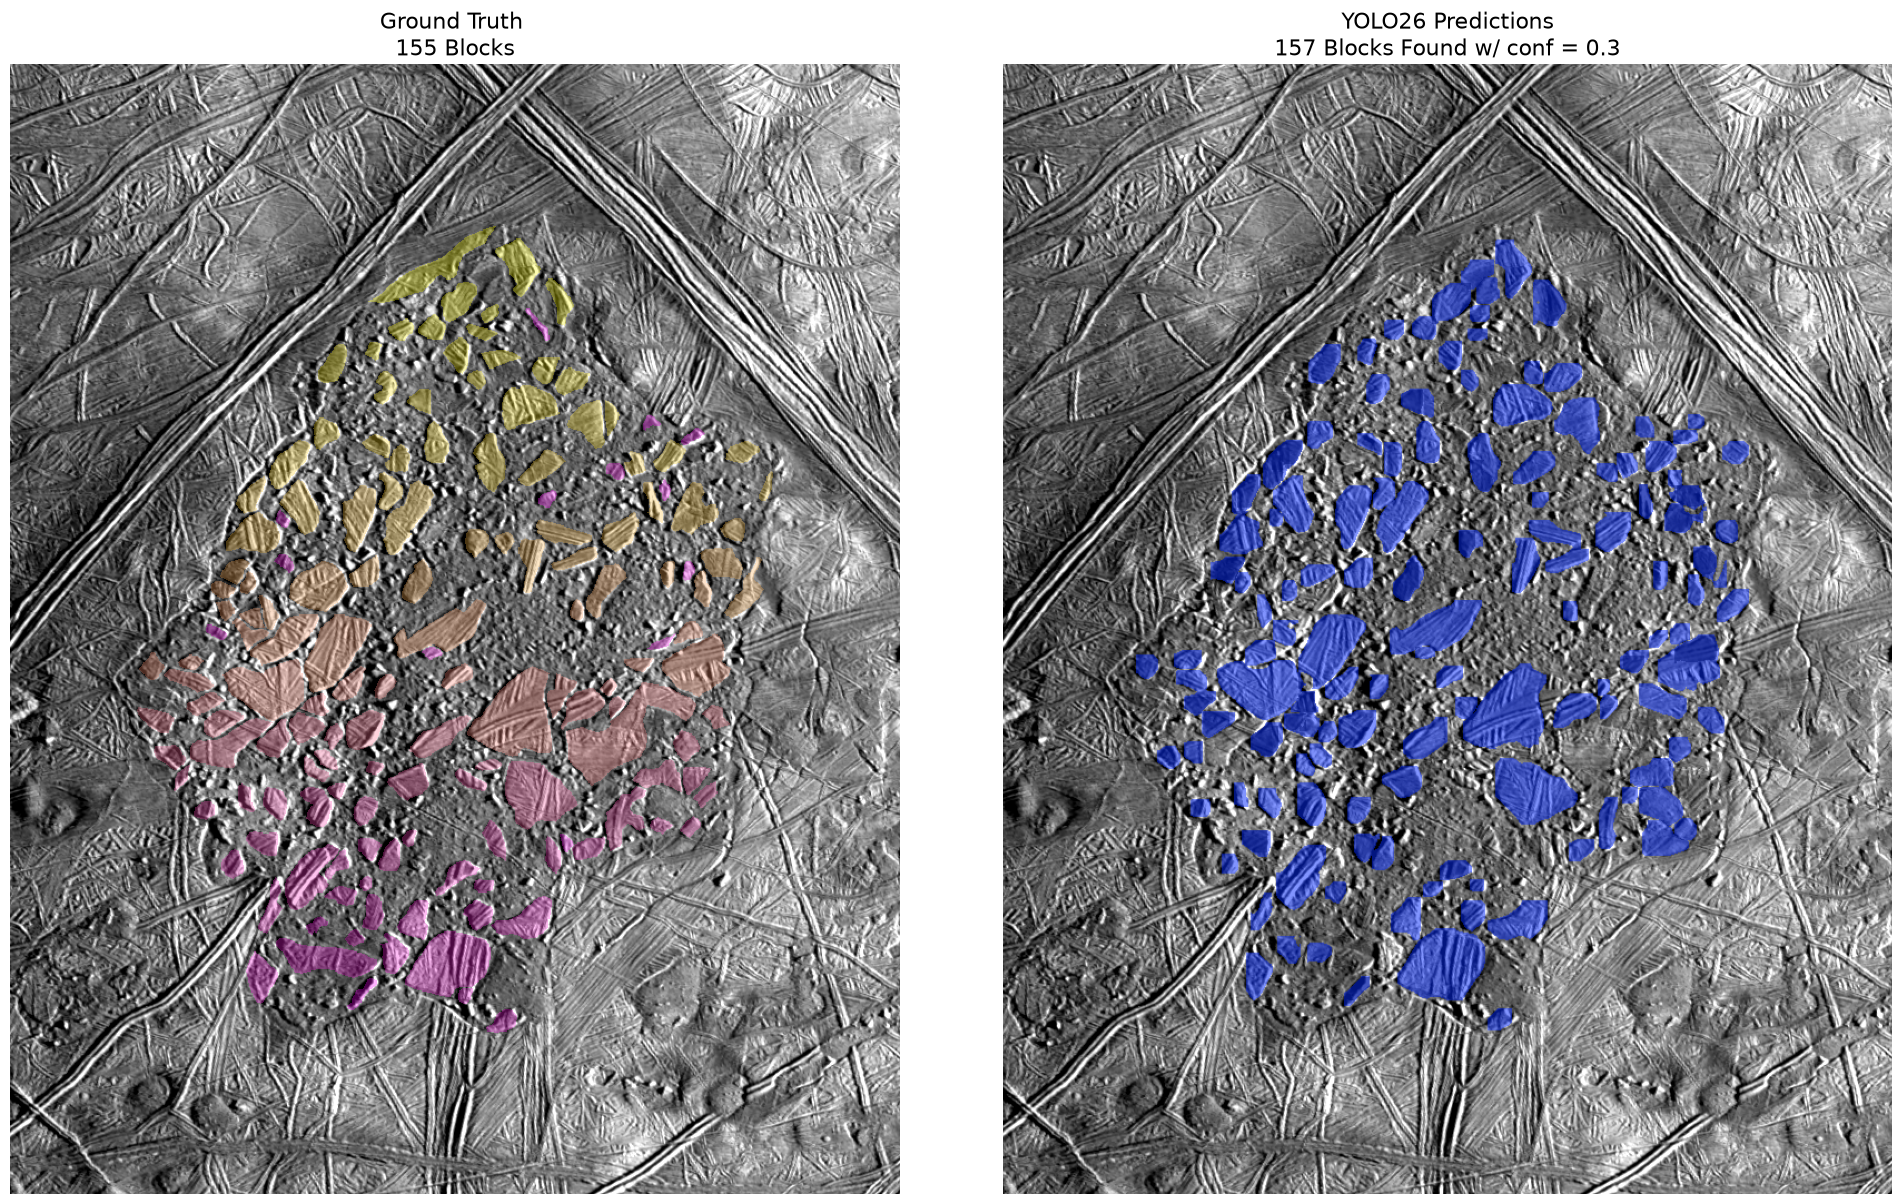

In [28]:
# define model run to visualize
model_run = "run_11_yolo26s"

# define directories to ground truth image/mask and model weights
img_path = os.path.join(data_dir, 'stitched/images/Chaos_Co.tif')
mask_path = os.path.join(data_dir, 'stitched/masks/Chaos_Co.tif')
weights_path = f"../results/runs/{model_run}/weights/best.pt"

# load the YOLO model
yolo_model = YOLO(weights_path)

# read and normalize TIFF image
print(f"Processing {os.path.basename(img_path)}...")
with rasterio.open(img_path) as src:
    img_data = src.read(1)
    
    # global normalization
    valid_pixels = img_data[~np.isnan(img_data)]
    vmin, vmax = np.percentile(valid_pixels, [2, 98])
    
    # clean and scale to 8-bit
    img_data = np.nan_to_num(img_data, nan=vmin)
    img_data = np.clip((img_data - vmin) / (vmax - vmin), 0, 1)
    img_8bit = (img_data * 255).astype(np.uint8)
    
    # convert to RGB
    img_rgb = cv2.cvtColor(img_8bit, cv2.COLOR_GRAY2RGB)

# read in ground truth mask
with rasterio.open(mask_path) as src:
    true_mask = src.read(1)

# define confidence threshold for plotting
conf = 0.3

# run YOLO predictions
results = yolo_model.predict(source=img_rgb, conf=conf, retina_masks=True, imgsz=img_rgb.shape[:2], device='mps')

# extract predicted image without boxes and labels
predicted_img = results[0].plot(labels=False, conf=False, boxes=False)

# plot both side by side
fig, axes = plt.subplots(1, 2, figsize=(20, 12))

# ground truth
axes[0].imshow(img_rgb)
transparent_true_mask = np.ma.masked_where(true_mask == 0, true_mask)
axes[0].imshow(transparent_true_mask, cmap='spring', alpha=0.3, interpolation='nearest')
axes[0].set_title(f"Ground Truth \n{len(np.unique(true_mask))-1} Blocks", fontsize=16)
axes[0].axis('off')

# YOLO predictions
axes[1].imshow(predicted_img[:, :, ::-1])
num_predictions = len(results[0].boxes) if results[0].boxes else 0
axes[1].set_title(f"YOLO26 Predictions\n{num_predictions} Blocks Found w/ conf = {conf}", fontsize=16)
axes[1].axis('off')

plt.tight_layout()
plt.show()

WARNING ⚠️ imgsz=[1455, 1244] must be multiple of max stride 32, updating to [1472, 1248]


,Human Blocks,AI Preds,Recall (%),Precision (%),F1-Score (%),Pixel IoU (%),True Coverage (%),Pred Coverage (%)
Region,,,,,,,,
Chaos_bb,92,119,92.4,84.9,88.5,64.6,3.2,3.9


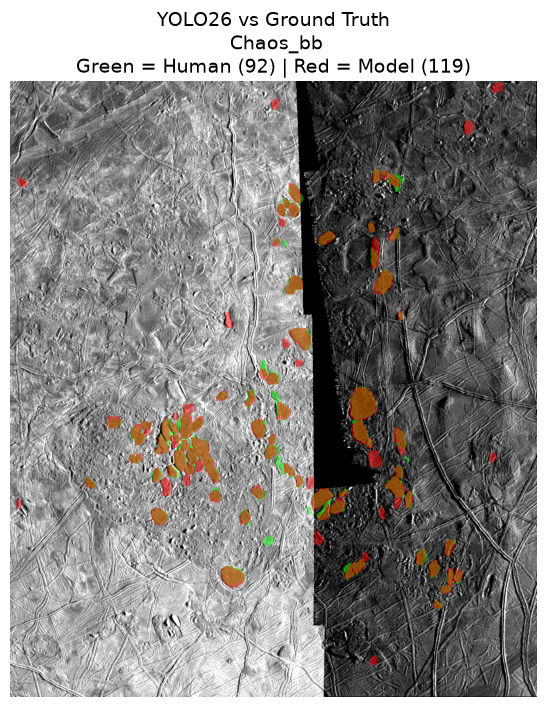

In [91]:
import os
import cv2
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from ultralytics import YOLO

# define model run to visualize
model_run = "run_08_yolo26s"
data_dir = os.path.abspath("../data/plates_cropped")
chaos_region = "Chaos_bb"

# define directories to ground truth image/mask and model weights
img_path = os.path.join(data_dir, f'stitched/images/{chaos_region}.tif')
mask_path = os.path.join(data_dir, f'stitched/masks/{chaos_region}.tif')
weights_path = f"../results/runs/{model_run}/weights/best.pt"

# load the YOLO model
yolo_model = YOLO(weights_path)

# load the YOLO model
yolo_model = YOLO(weights_path)

with rasterio.open(img_path) as src:
    img_data_raw = src.read(1)
    
    valid_pixels_mask = ~np.isnan(img_data_raw)
    valid_pixels = img_data_raw[valid_pixels_mask]
    total_valid_area = valid_pixels.size
    
    vmin, vmax = np.percentile(valid_pixels, [2, 98])
    
    img_data = np.nan_to_num(img_data_raw, nan=vmin)
    img_data = np.clip((img_data - vmin) / (vmax - vmin), 0, 1)
    img_8bit = (img_data * 255).astype(np.uint8)
    
    # Create the base RGB image (This will be our canvas)
    img_rgb = cv2.cvtColor(img_8bit, cv2.COLOR_GRAY2RGB)

# read in the ground truth mask
with rasterio.open(mask_path) as src:
    true_mask = src.read(1)

# Convert instance mask to binary (1s and 0s)
binary_true = (true_mask > 0).astype(np.uint8)
num_true = len(np.unique(true_mask)) - 1

# Create a pure Green image the exact same size as the canvas
green_overlay = np.zeros_like(img_rgb)
green_overlay[:, :] = [0, 255, 0] # RGB Green

# get YOLO predictions
results = yolo_model.predict(source=img_rgb, conf=0.25, retina_masks=True, imgsz=img_rgb.shape[:2], device='mps', verbose=False)
num_predictions = len(results[0].boxes) if results[0].boxes else 0

# Extract masks
height, width = img_rgb.shape[:2]
binary_pred = np.zeros((height, width), dtype=np.uint8)

# Initialize stats variables
human_blocks_detected = 0  # True Positives (Recall basis)
ai_correct_predictions = 0 # True Positives (Precision basis)

if results[0].masks is not None:
    # Safely extract masks and resize them to match the original image exactly
    masks = results[0].masks.data.cpu().numpy()

    matched_human_blocks = set()
    
    for pred in masks:
        pred_resized = cv2.resize(pred, (width, height), interpolation=cv2.INTER_NEAREST)
        pred_binary_single = (pred_resized > 0)
        
        overlapping_human_ids = np.unique(true_mask[pred_binary_single])
        overlapping_human_ids = overlapping_human_ids[overlapping_human_ids != 0]
        
        if len(overlapping_human_ids) > 0:
            matched_human_blocks.update(overlapping_human_ids)
            ai_correct_predictions += 1
            
    human_blocks_detected = len(matched_human_blocks)
    
    # YOLO outputs masks in (N, H, W). We sum them to make a single (H, W) mask
    summed_mask = np.sum(masks, axis=0)
    summed_mask = cv2.resize(summed_mask, (width, height), interpolation=cv2.INTER_NEAREST)
    binary_pred = (summed_mask > 0).astype(np.uint8)


# Instance Metrics
recall = (human_blocks_detected / num_true) * 100 if num_true > 0 else 0
precision = (ai_correct_predictions / num_predictions) * 100 if num_predictions > 0 else 0
f1_score = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

# Spatial / Pixel Metrics (IoU)
intersection = np.logical_and(binary_true, binary_pred).sum()
union = np.logical_or(binary_true, binary_pred).sum()
pixel_iou = (intersection / union) * 100 if union > 0 else 0

# Area Estimation (% of valid region covered in blocks)
true_area_pct = (np.sum(binary_true) / total_valid_area) * 100 if total_valid_area > 0 else 0
pred_area_pct = (np.sum(binary_pred) / total_valid_area) * 100 if total_valid_area > 0 else 0

 
# Create a pure Red image the exact same size as the canvas
red_overlay = np.zeros_like(img_rgb)
red_overlay[:, :] = [255, 0, 0] # RGB Red


# Add Green Ground Truth
mask_green_indices = binary_true == 1
img_rgb[mask_green_indices] = cv2.addWeighted(img_rgb, 0.5, green_overlay, 0.5, 0)[mask_green_indices]

# Add Red Predictions
mask_red_indices = binary_pred == 1
img_rgb[mask_red_indices] = cv2.addWeighted(img_rgb, 0.5, red_overlay, 0.5, 0)[mask_red_indices]

# plot the image with overlay
fig, ax = plt.subplots(1, 1, figsize=(8,8))

# plot the fully blended image
ax.imshow(img_rgb)

# add Legend and Title
ax.set_title(f"YOLO26 vs Ground Truth\n {chaos_region}\nGreen = Human ({num_true}) | Red = Model ({num_predictions})", fontsize=14)
ax.axis('off')

df_stats = pd.DataFrame([{
    "Region": chaos_region,
    "Human Blocks": num_true,
    "AI Preds": num_predictions,
    "Recall (%)": round(recall, 1),
    "Precision (%)": round(precision, 1),
    "F1-Score (%)": round(f1_score, 1),
    "Pixel IoU (%)": round(pixel_iou, 1),
    "True Coverage (%)": round(true_area_pct, 1),
    "Pred Coverage (%)": round(pred_area_pct, 1)
}])

df_stats.set_index("Region", inplace=True)
display(df_stats) # Renders a beautiful HTML table directly below the image!

plt.savefig(
    fname = f"../figures/run_11_yolos/{chaos_region}_overlay_run11.png",
    dpi = 200,
)